In [1]:
print("Day 4")

Day 4


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)

data = {
    "Age": np.random.randint(18, 65, 120),
    "Salary": np.random.normal(60000, 15000, 120).astype(int),
    "Experience": np.random.randint(0, 40, 120),
    "Hours_Worked": np.random.normal(40, 8, 120),
    "Performance_Score": np.random.normal(70, 10, 120)
}

df = pd.DataFrame(data)

df.head()


,Age,Salary,Experience,Hours_Worked,Performance_Score
0,56,78182,21,34.559965,84.367547
1,46,78502,21,37.892753,62.983000
2,32,36387,29,37.754761,68.567167
3,60,69569,37,35.168193,63.993953
4,25,29333,37,35.605977,66.918220


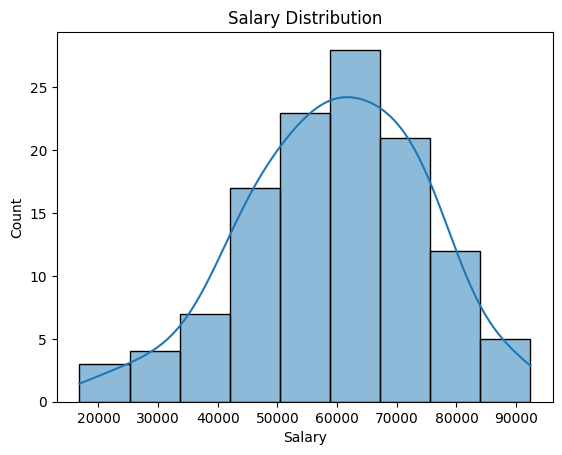

In [8]:
plt.figure()
sns.histplot(df["Salary"], kde=True)
plt.title("Salary Distribution")
plt.show()


In [9]:
Q1 = df["Salary"].quantile(0.25)
Q3 = df["Salary"].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers_iqr = df[(df["Salary"] < lower) | (df["Salary"] > upper)]
outliers_iqr


,Age,Salary,Experience,Hours_Worked,Performance_Score
110,56,16808,0,50.870533,70.237515


In [12]:
mean = df["Salary"].mean()
std = df["Salary"].std()

df["z_score"] = (df["Salary"] - mean) / std

outliers_z = df[df["z_score"].abs() > 3]
outliers_z


,Age,Salary,Experience,Hours_Worked,Performance_Score,z_score


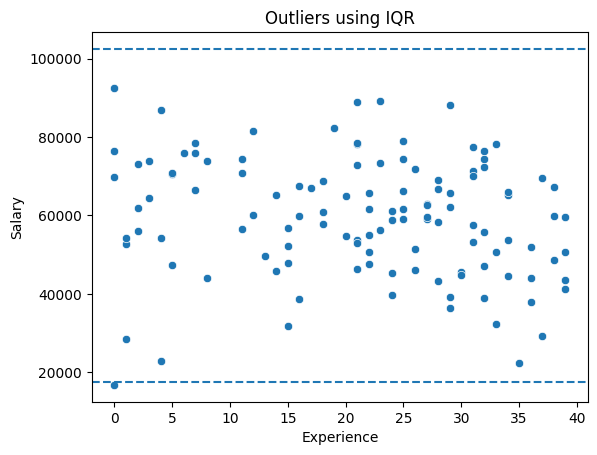

In [15]:
plt.figure()
sns.scatterplot(x=df["Experience"], y=df["Salary"])
plt.axhline(upper, linestyle="--")
plt.axhline(lower, linestyle="--")
plt.title("Outliers using IQR")
plt.show()

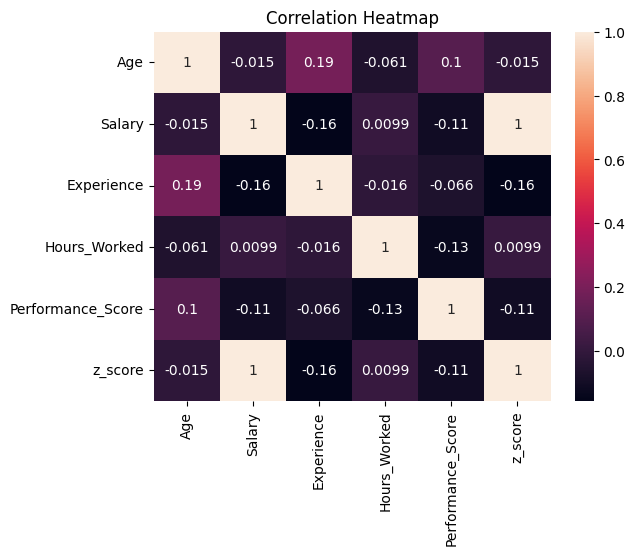

In [16]:
plt.figure()
sns.heatmap(df.corr(), annot=True)
plt.title("Correlation Heatmap")
plt.show()

In [17]:
corr_pairs = df.corr().unstack().sort_values(ascending=False)
corr_pairs = corr_pairs[corr_pairs < 1]
corr_pairs.head(5)

z_score     Salary               1.000000
Salary      z_score              1.000000
Experience  Age                  0.189197
Age         Experience           0.189197
            Performance_Score    0.100600
dtype: float64

In [18]:
range_metric = lambda col: col.max() - col.min()

range_metric(df["Salary"])


np.int64(75572)

In [21]:
df2 = pd.read_csv('../data/train.csv')
df2

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


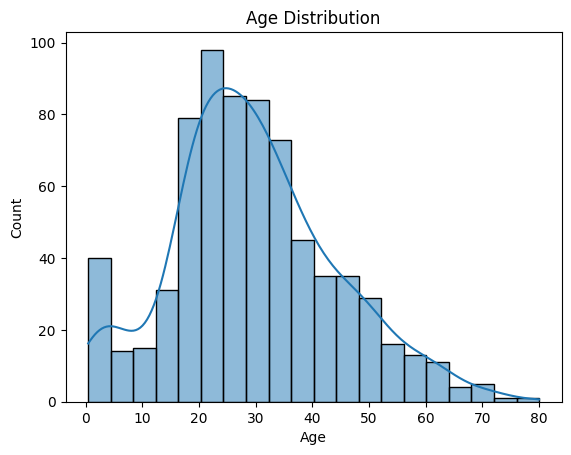

In [22]:
plt.figure()
sns.histplot(df2["Age"], kde=True)
plt.title("Age Distribution")
plt.show()


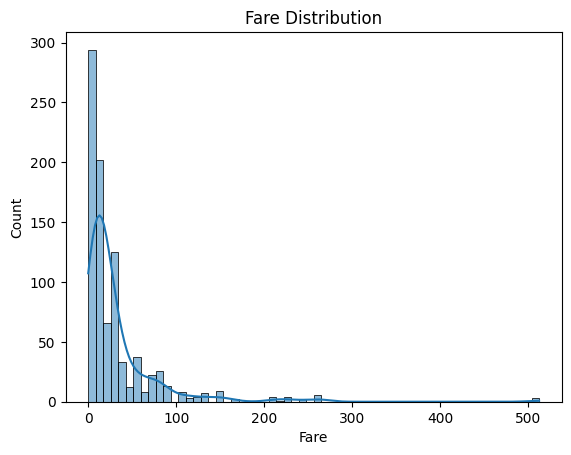

In [26]:
plt.figure()
sns.histplot(df2["Fare"], kde=True)
plt.title("Fare Distribution")
plt.show()


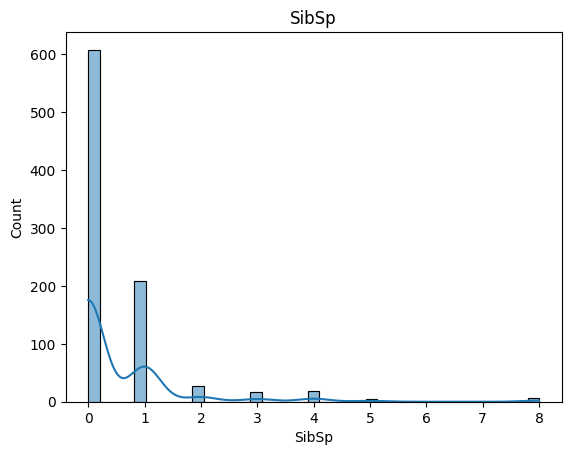

In [25]:
plt.figure()
sns.histplot(df2["SibSp"], kde=True)
plt.title("SibSp")
plt.show()


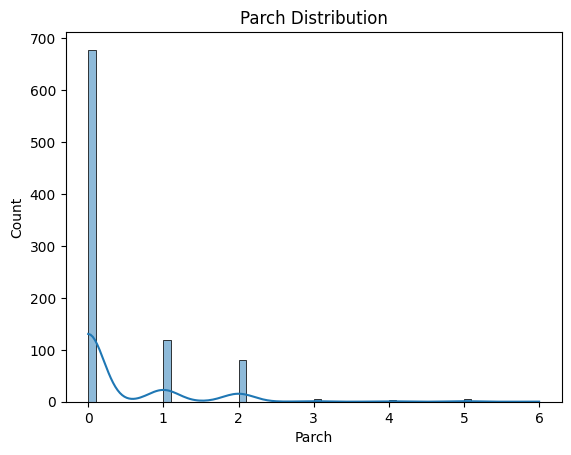

In [27]:
plt.figure()
sns.histplot(df2["Parch"], kde=True)
plt.title("Parch Distribution")
plt.show()


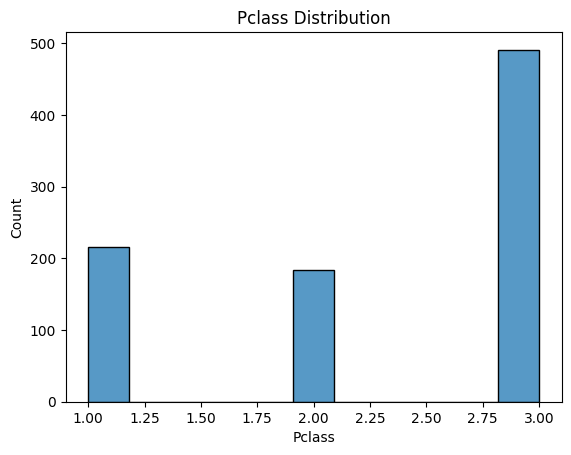

In [40]:
plt.figure()
sns.histplot(df2["Pclass"])
plt.title("Pclass Distribution")
plt.show()


In [49]:
Q1 = df2["Fare"].quantile(0.25)
Q3 = df2["Fare"].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers_iqr = df2[(df2["Fare"] < lower) | (df2["Fare"] > upper)]
outliers_iqr


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,z_score
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,0.786404
27,28,0,1,"Fortune, Mr. Charles Alexander",male,19.0,3,2,19950,263.0000,C23 C25 C27,S,4.644393
31,32,1,1,"Spencer, Mrs. William Augustus (Marie Eugenie)",female,NaN,1,0,PC 17569,146.5208,B78,C,2.300437
34,35,0,1,"Meyer, Mr. Edgar Joseph",male,28.0,1,0,PC 17604,82.1708,NaN,C,1.005497
52,53,1,1,"Harper, Mrs. Henry Sleeper (Myna Haxtun)",female,49.0,1,0,PC 17572,76.7292,D33,C,0.895994
...,...,...,...,...,...,...,...,...,...,...,...,...,...
846,847,0,3,"Sage, Mr. Douglas Bullen",male,NaN,8,2,CA. 2343,69.5500,NaN,S,0.751524
849,850,1,1,"Goldenberg, Mrs. Samuel L (Edwiga Grabowska)",female,NaN,1,0,17453,89.1042,C92,C,1.145020
856,857,1,1,"Wick, Mrs. George Dennick (Mary Hitchcock)",female,45.0,1,1,36928,164.8667,NaN,S,2.669618
863,864,0,3,"Sage, Miss. Dorothy Edith ""Dolly""",female,NaN,8,2,CA. 2343,69.5500,NaN,S,0.751524


In [47]:
lower

np.float64(-61.358399999999996)

In [48]:
upper

np.float64(100.2688)

In [45]:
mean = df2["Fare"].mean()
std = df2["Fare"].std()

df2["z_score"] = (df2["Fare"] - mean) / std

outliers_z = df2[df2["z_score"].abs() > 3]
outliers_z


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,z_score
27,28,0,1,"Fortune, Mr. Charles Alexander",male,19.0,3,2,19950,263.0000,C23 C25 C27,S,4.644393
88,89,1,1,"Fortune, Miss. Mabel Helen",female,23.0,3,2,19950,263.0000,C23 C25 C27,S,4.644393
118,119,0,1,"Baxter, Mr. Quigg Edmond",male,24.0,0,1,PC 17558,247.5208,B58 B60,C,4.332899
258,259,1,1,"Ward, Miss. Anna",female,35.0,0,0,PC 17755,512.3292,NaN,C,9.661740
299,300,1,1,"Baxter, Mrs. James (Helene DeLaudeniere Chaput)",female,50.0,0,1,PC 17558,247.5208,B58 B60,C,4.332899
311,312,1,1,"Ryerson, Miss. Emily Borie",female,18.0,2,2,PC 17608,262.3750,B57 B59 B63 B66,C,4.631815
341,342,1,1,"Fortune, Miss. Alice Elizabeth",female,24.0,3,2,19950,263.0000,C23 C25 C27,S,4.644393
377,378,0,1,"Widener, Mr. Harry Elkins",male,27.0,0,2,113503,211.5000,C82,C,3.608038
380,381,1,1,"Bidois, Miss. Rosalie",female,42.0,0,0,PC 17757,227.5250,NaN,C,3.930516
438,439,0,1,"Fortune, Mr. Mark",male,64.0,1,4,19950,263.0000,C23 C25 C27,S,4.644393


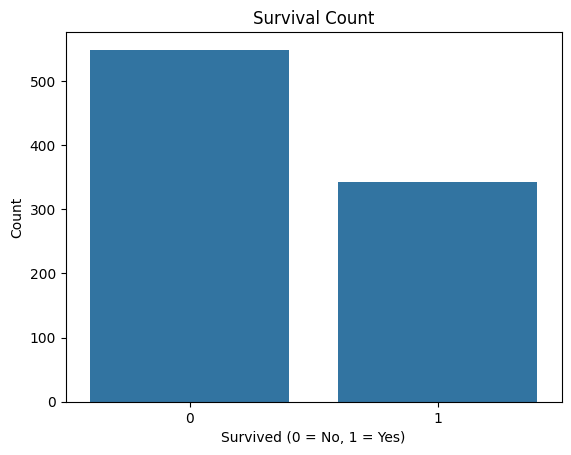

In [52]:
plt.figure()
sns.countplot(x=df2["Survived"])
plt.title("Survival Count")
plt.xlabel("Survived (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.show()


In [55]:
bins = [0, 12, 18, 35, 60, 100]
labels = ["Child", "Teen", "Young Adult", "Adult", "Senior"]

df2["AgeGroup"] = pd.cut(df2["Age"], bins=bins, labels=labels)


/tmp/ipykernel_5924/3795176725.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  survival_rate = df2.groupby("AgeGroup")["Survived"].mean()


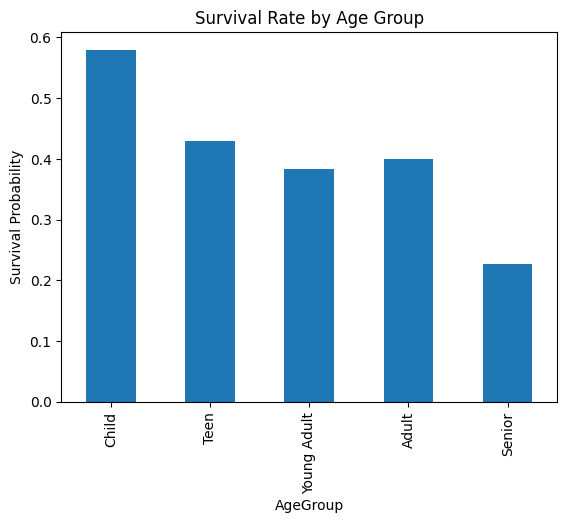

In [56]:
survival_rate = df2.groupby("AgeGroup")["Survived"].mean()

plt.figure()
survival_rate.plot(kind="bar")
plt.title("Survival Rate by Age Group")
plt.ylabel("Survival Probability")
plt.show()
